https://www.kaggle.com/c/bike-sharing-demand/data?select=train.csv

In [51]:
# 바이크 대여량 예측 모델

In [52]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_log_error

# ✅ 한글 폰트 설정 (Windows: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

In [53]:
BSD_DF_train = pd.read_csv('./data/bike-sharing-demand/train.csv')
BSD_DF_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [54]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [55]:
BSD_DF_train.drop(columns=['datetime',]).corr()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948


In [56]:
BSD_DF_train['datetime'] = pd.to_datetime(BSD_DF_train['datetime'])

BSD_DF_train['year'] = BSD_DF_train['datetime'].dt.year
BSD_DF_train['month'] = BSD_DF_train['datetime'].dt.month
BSD_DF_train['day'] = BSD_DF_train['datetime'].dt.day
BSD_DF_train['hour'] = BSD_DF_train['datetime'].dt.hour
BSD_DF_train['weekday'] = BSD_DF_train['datetime'].dt.weekday


In [57]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  weekday     10886 non-

In [58]:
BSD_DF_train = BSD_DF_train.drop(columns=['datetime', 'casual', 'registered'])
BSD_DF_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   count       10886 non-null  int64  
 9   year        10886 non-null  int32  
 10  month       10886 non-null  int32  
 11  day         10886 non-null  int32  
 12  hour        10886 non-null  int32  
 13  weekday     10886 non-null  int32  
dtypes: float64(3), int32(5), int64(6)
memory usage: 978.2 KB


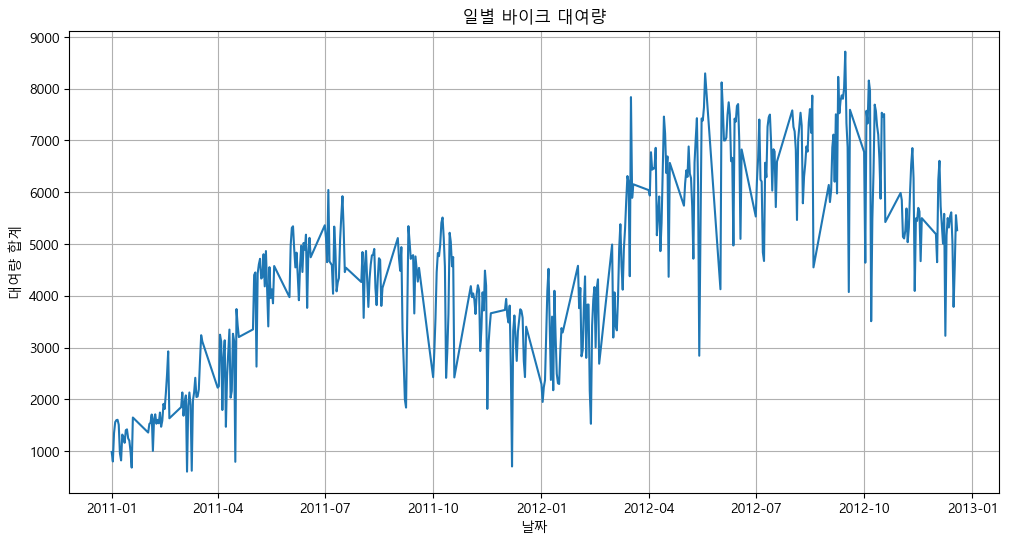

In [59]:
import matplotlib.pyplot as plt

# 'day' 기준으로 대여량 합계 집계
daily_rentals = BSD_DF_train.groupby(['year', 'month', 'day'])['count'].sum()

# 인덱스를 datetime으로 변환 (year, month, day 합쳐서)
daily_rentals.index = pd.to_datetime(daily_rentals.index.map(lambda x: f"{x[0]}-{x[1]}-{x[2]}"))

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(daily_rentals.index, daily_rentals.values)
plt.title('일별 바이크 대여량')
plt.xlabel('날짜')
plt.ylabel('대여량 합계')
plt.grid(True)
plt.show()


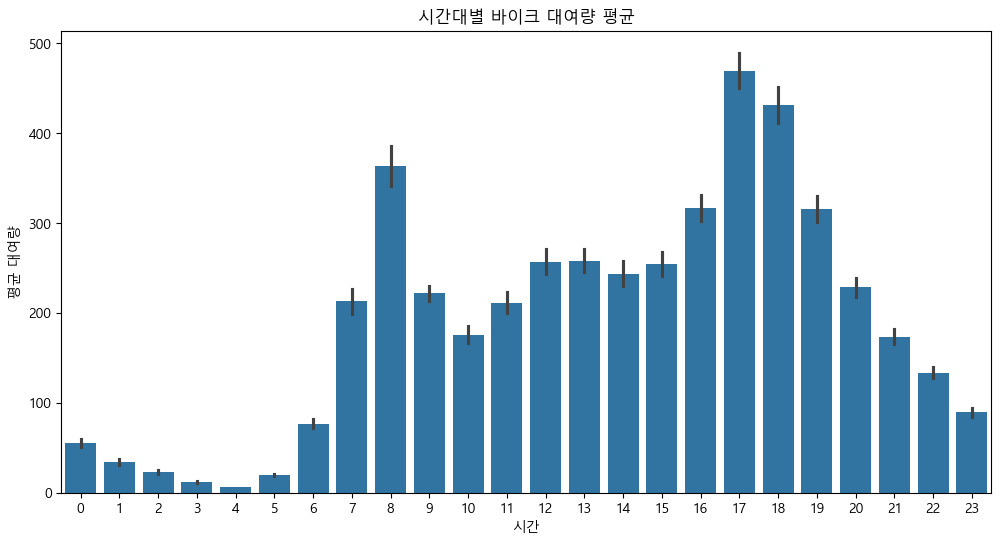

In [60]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='hour', y='count', data=BSD_DF_train)
plt.title('시간대별 바이크 대여량 평균')
plt.xlabel('시간')
plt.ylabel('평균 대여량')
plt.show()


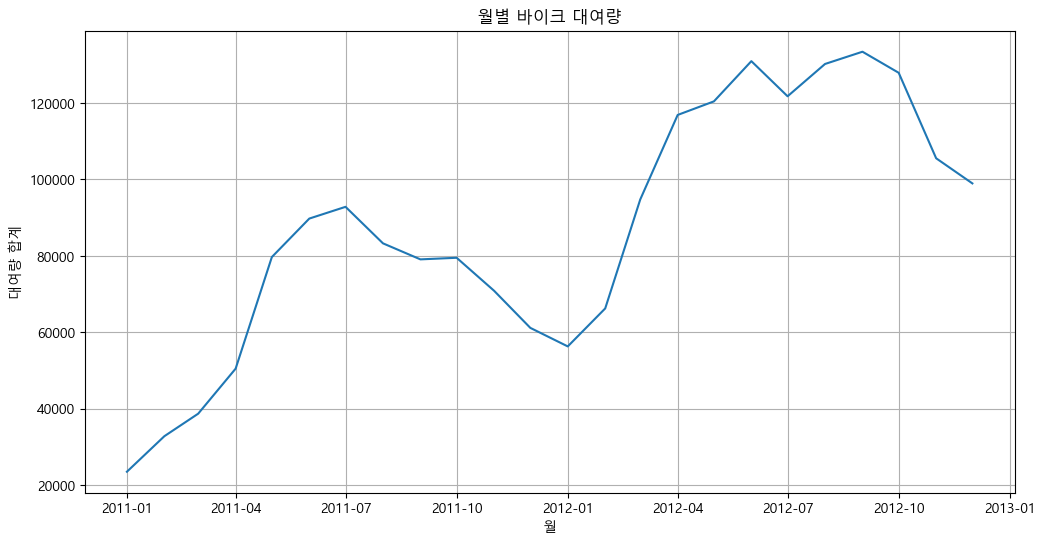

In [61]:
monthly_rentals = BSD_DF_train.groupby(['year', 'month'])['count'].sum()
monthly_rentals.index = pd.to_datetime(monthly_rentals.index.map(lambda x: f"{x[0]}-{x[1]}"))

plt.figure(figsize=(12, 6))
plt.plot(monthly_rentals.index, monthly_rentals.values)
plt.title('월별 바이크 대여량')
plt.xlabel('월')
plt.ylabel('대여량 합계')
plt.grid(True)
plt.show()


In [62]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   count       10886 non-null  int64  
 9   year        10886 non-null  int32  
 10  month       10886 non-null  int32  
 11  day         10886 non-null  int32  
 12  hour        10886 non-null  int32  
 13  weekday     10886 non-null  int32  
dtypes: float64(3), int32(5), int64(6)
memory usage: 978.2 KB


In [63]:
BSD_DF_train[['temp', 'atemp', 'humidity', 'windspeed','count']].corr()

,temp,atemp,humidity,windspeed,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.101369
count,0.394454,0.389784,-0.317371,0.101369,1.000000


In [64]:
corr_matrix = BSD_DF_train.corr(numeric_only=True)  # 숫자형만 상관계수 계산
corr_matrix

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour,weekday
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.163439,-0.004797,0.971524,0.001729,-0.006546,-0.010553
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,-0.005393,0.012021,0.001731,-0.015877,-0.000354,-0.191832
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,0.011594,-0.002482,-0.003394,0.009829,0.002780,-0.704267
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.128655,-0.012548,0.012144,-0.007890,-0.022740,-0.047692
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.394454,0.061226,0.257589,0.015551,0.145430,-0.038466
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.389784,0.058540,0.264173,0.011866,0.140343,-0.040235
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.317371,-0.078606,0.204537,-0.011335,-0.278011,-0.026507
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.101369,-0.015221,-0.150192,0.036157,0.146631,-0.024804
count,0.163439,-0.005393,0.011594,-0.128655,0.394454,0.389784,-0.317371,0.101369,1.000000,0.260403,0.166862,0.019826,0.400601,-0.002283
year,-0.004797,0.012021,-0.002482,-0.012548,0.061226,0.058540,-0.078606,-0.015221,0.260403,1.000000,-0.004932,0.001800,-0.004234,-0.003785


In [65]:
BSD_DF_train = BSD_DF_train.drop(columns=['windspeed','season'])

In [66]:
# weather == 4 제거 (악천후) -샘플이 1개밖에 없어 이상치로 간주
BSD_DF_train = BSD_DF_train[BSD_DF_train['weather'] != 4]

In [67]:
# 데이터 분리

# 입력 변수 X (count 컬럼 제외)
X = BSD_DF_train.drop(columns=['count'])
# 타겟 변수 y
y = BSD_DF_train['count']

In [68]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10885 entries, 0 to 10885
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   holiday     10885 non-null  int64  
 1   workingday  10885 non-null  int64  
 2   weather     10885 non-null  int64  
 3   temp        10885 non-null  float64
 4   atemp       10885 non-null  float64
 5   humidity    10885 non-null  int64  
 6   year        10885 non-null  int32  
 7   month       10885 non-null  int32  
 8   day         10885 non-null  int32  
 9   hour        10885 non-null  int32  
 10  weekday     10885 non-null  int32  
dtypes: float64(2), int32(5), int64(4)
memory usage: 807.9 KB


In [69]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [70]:
# 모델 학습
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# 예측
rf_pred = rf.predict(X_test)
# 평가
# MSE (음수로 반환되므로 부호 반전 필요)
neg_mse_scores = cross_val_score(
    rf, X, y,
    scoring='neg_mean_squared_error',
    cv=5
)
mse_scores = -neg_mse_scores
rmse_scores = np.sqrt(mse_scores)

# R² 점수
r2_scores = cross_val_score(
    rf, X, y,
    scoring='r2',
    cv=5
)

# 결과 출력
print("교차검증 결과 (5-fold):")
print(f"평균 MSE:  {mse_scores.mean():.4f}")
print(f"평균 RMSE: {rmse_scores.mean():.4f}")
print(f"평균 R²:   {r2_scores.mean():.4f}")

교차검증 결과 (5-fold):
평균 MSE:  5481.1711
평균 RMSE: 72.9212
평균 R²:   0.7075


       feature  importance
9         hour    0.602321
6         year    0.089006
3         temp    0.071879
7        month    0.060101
1   workingday    0.054847
10     weekday    0.035520
5     humidity    0.030359
4        atemp    0.028998
2      weather    0.013906
8          day    0.011036
0      holiday    0.002026


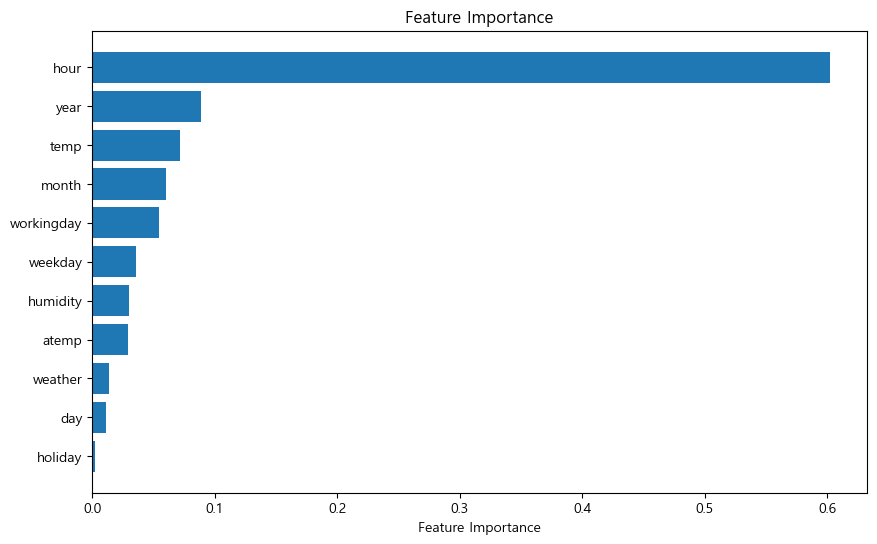

In [71]:
# 학습된 모델 rf가 있어야 합니다 (이미 학습한 상태)

# 1. 피처 중요도 추출
importances = rf.feature_importances_

# 2. 피처 이름 (X의 컬럼명)
feature_names = X.columns

# 3. 데이터프레임 생성 (정렬을 위해)
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# 4. 중요도 내림차순 정렬
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

# 5. 출력
print(feat_imp_df)

# 6. 시각화 (바 차트)
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'])
plt.gca().invert_yaxis()  # 중요도 높은 순서대로 위로
plt.xlabel('Feature Importance')
plt.title('Feature Importance')
plt.show()


In [23]:
# 중요도 낮은 컬럼 3개 제거

In [24]:
# season, day 컬럼 제거
X = X.drop(columns=[ 'day','atemp','holiday'])

In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10885 entries, 0 to 10885
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   workingday  10885 non-null  int64  
 1   weather     10885 non-null  int64  
 2   temp        10885 non-null  float64
 3   humidity    10885 non-null  int64  
 4   year        10885 non-null  int32  
 5   month       10885 non-null  int32  
 6   hour        10885 non-null  int32  
 7   weekday     10885 non-null  int32  
dtypes: float64(1), int32(4), int64(3)
memory usage: 595.3 KB


In [26]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# 모델 생성 (기본 하이퍼파라미터)
rf = RandomForestRegressor(random_state=42)

# 교차검증 (5-fold) MSE (음수값) 계산
neg_mse_scores = cross_val_score(
    rf, X_train, y_train,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)
mse_scores = -neg_mse_scores
rmse_scores = np.sqrt(mse_scores)

# 교차검증 R2 점수 계산
r2_scores = cross_val_score(
    rf, X_train, y_train,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("교차검증 결과 (5-fold):")
print(f"평균 MSE:  {mse_scores.mean():.4f}")
print(f"평균 RMSE: {rmse_scores.mean():.4f}")
print(f"평균 R2:   {r2_scores.mean():.4f}")

# 교차검증 후 전체 train 데이터로 학습
rf.fit(X_train, y_train)

# 테스트셋 예측
y_pred = rf.predict(X_test)

# 테스트셋 평가
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

print("\n테스트셋 평가:")
print(f"MSE:  {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R2:   {r2_test:.4f}")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.0s finished


교차검증 결과 (5-fold):
평균 MSE:  1705.6320
평균 RMSE: 41.2939
평균 R2:   0.9474

테스트셋 평가:
MSE:  1789.2236
RMSE: 42.2992
R2:   0.9475


In [28]:
# 데이터 복사 및 변환 (필요시)
X_train = X_train.values.copy() if hasattr(X_train, 'values') else np.asarray(X_train).copy()
y_train = y_train.values.copy() if hasattr(y_train, 'values') else np.asarray(y_train).copy()

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42, eval_metric='rmse', use_label_encoder=False),
    "LGBMRegressor": LGBMRegressor(random_state=42)
}

for name, model in models.items():
    # MSE (음수값) 교차검증 점수
    neg_mse_scores = cross_val_score(
        model, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    mse_scores = -neg_mse_scores
    rmse_scores = np.sqrt(mse_scores)

    # R2 교차검증 점수
    r2_scores = cross_val_score(
        model, X_train, y_train,
        scoring='r2',
        cv=5,
        n_jobs=-1
    )

    print(f"{name} 교차검증 결과 (5-fold):")
    print(f"평균 MSE:  {mse_scores.mean():.4f}")
    print(f"평균 RMSE: {rmse_scores.mean():.4f}")
    print(f"평균 R2:   {r2_scores.mean():.4f}")
    print("-" * 30)


LinearRegression 교차검증 결과 (5-fold):
평균 MSE:  19961.4491
평균 RMSE: 141.2690
평균 R2:   0.3850
------------------------------
RandomForest 교차검증 결과 (5-fold):
평균 MSE:  1705.6320
평균 RMSE: 41.2939
평균 R2:   0.9474
------------------------------
GradientBoosting 교차검증 결과 (5-fold):
평균 MSE:  4252.3163
평균 RMSE: 65.1728
평균 R2:   0.8689
------------------------------
XGBRegressor 교차검증 결과 (5-fold):
평균 MSE:  1598.5463
평균 RMSE: 39.9638
평균 R2:   0.9508
------------------------------
LGBMRegressor 교차검증 결과 (5-fold):
평균 MSE:  1582.1956
평균 RMSE: 39.7684
평균 R2:   0.9512
------------------------------


In [29]:
model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 평가
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

print("LGBMRegressor 테스트셋 평가 결과:")
print(f"MSE:  {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R2:   {r2_test:.4f}")


LGBMRegressor 테스트셋 평가 결과:
MSE:  1635.0653
RMSE: 40.4359
R2:   0.9521


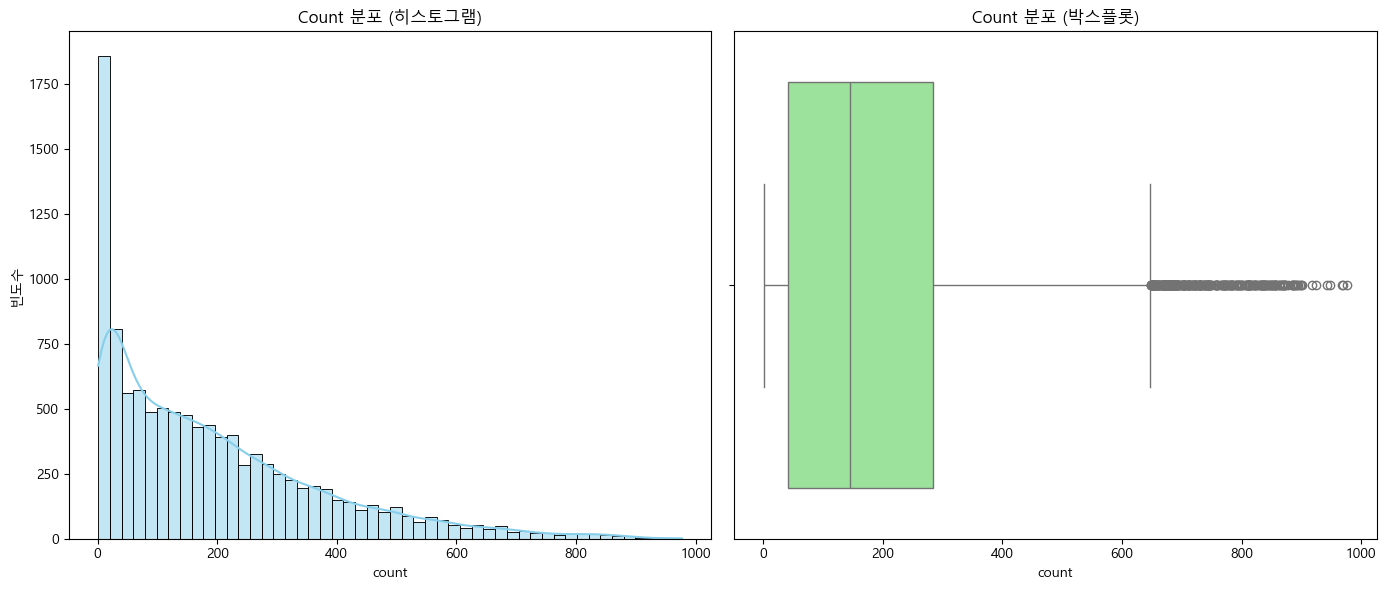

In [30]:
plt.figure(figsize=(14, 6))

# 히스토그램 - 분포 확인용
plt.subplot(1, 2, 1)
sns.histplot(y, bins=50, kde=True, color='skyblue')
plt.title('Count 분포 (히스토그램)')
plt.xlabel('count')
plt.ylabel('빈도수')

# 박스플롯 - 이상치 및 분포 범위 확인용
plt.subplot(1, 2, 2)
sns.boxplot(x=y, color='lightgreen')
plt.title('Count 분포 (박스플롯)')
plt.xlabel('count')

plt.tight_layout()
plt.show()


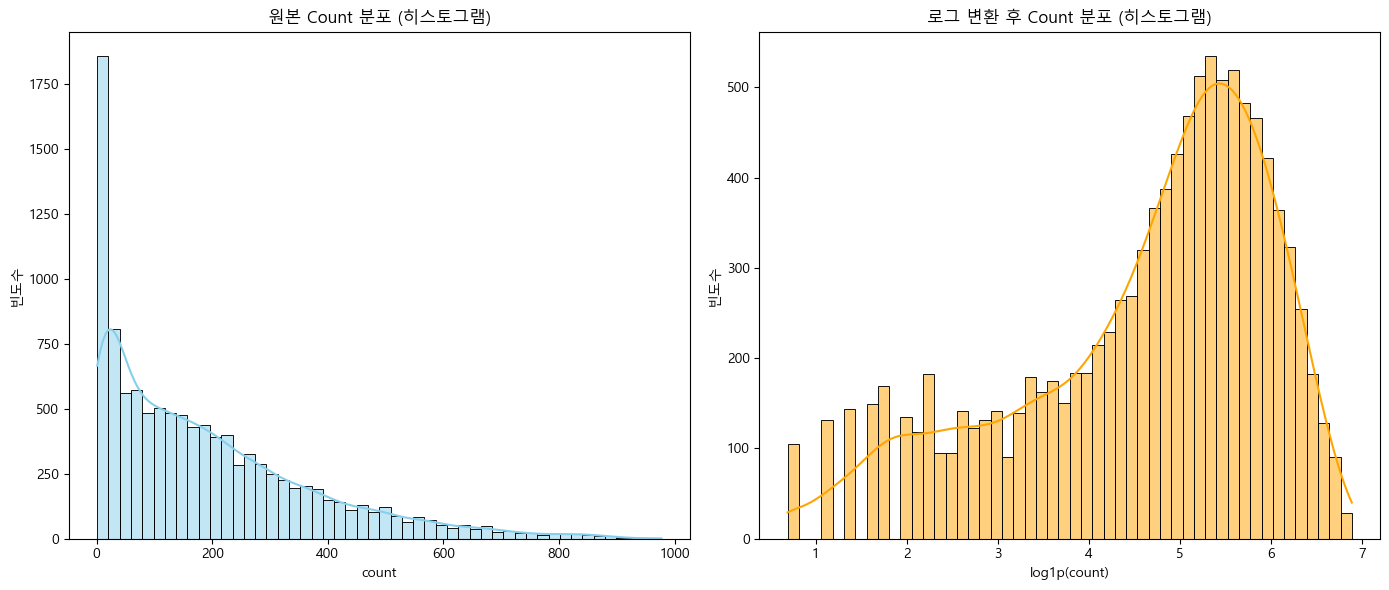

In [31]:
# 로그 변환
y_log = np.log1p(y)  # log(1 + y)

plt.figure(figsize=(14, 6))

# 원본 y 분포 (히스토그램)
plt.subplot(1, 2, 1)
sns.histplot(y, bins=50, kde=True, color='skyblue')
plt.title('원본 Count 분포 (히스토그램)')
plt.xlabel('count')
plt.ylabel('빈도수')

# 로그 변환 후 y 분포 (히스토그램)
plt.subplot(1, 2, 2)
sns.histplot(y_log, bins=50, kde=True, color='orange')
plt.title('로그 변환 후 Count 분포 (히스토그램)')
plt.xlabel('log1p(count)')
plt.ylabel('빈도수')

plt.tight_layout()
plt.show()


In [32]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42),
    "LGBMRegressor": LGBMRegressor(random_state=42)
}

for name, model in models.items():
    # 1) 원본 y로 학습
    model.fit(X_train, y_train)
    
    # 2) 테스트셋 예측 (원본 스케일)
    y_pred = model.predict(X_test)
    y_pred = np.maximum(y_pred, 0)  # 음수 예측 방지 (필요시)
    
    # 3) 평가 (실제 y_test와 비교)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # 4) RMSLE 계산 (실제값과 예측값 모두에 log1p 적용)
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(y_pred)))
    
    print(f"{name} (원본 타깃 전체 학습 후 테스트셋 평가):")
    print(f"  MSE:   {mse:.4f}")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  R2:    {r2:.4f}")
    print(f"  RMSLE: {rmsle:.4f}")
    print("-" * 40)


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


LinearRegression (원본 타깃 전체 학습 후 테스트셋 평가):
  MSE:   20617.2857
  RMSE:  143.5872
  R2:    0.3956
  RMSLE: 1.3063
----------------------------------------


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


RandomForest (원본 타깃 전체 학습 후 테스트셋 평가):
  MSE:   1789.2236
  RMSE:  42.2992
  R2:    0.9475
  RMSLE: 0.3200
----------------------------------------
GradientBoosting (원본 타깃 전체 학습 후 테스트셋 평가):
  MSE:   4902.2663
  RMSE:  70.0162
  R2:    0.8563
  RMSLE: 0.7120
----------------------------------------
XGBRegressor (원본 타깃 전체 학습 후 테스트셋 평가):
  MSE:   1503.5418
  RMSE:  38.7755
  R2:    0.9559
  RMSLE: 0.4504
----------------------------------------
LGBMRegressor (원본 타깃 전체 학습 후 테스트셋 평가):
  MSE:   1633.6171
  RMSE:  40.4180
  R2:    0.9521
  RMSLE: 0.4446
----------------------------------------


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


| 모델                   | RMSE  | R²     | RMSLE  | 특징/추천 이유                                 |
| -------------------- | ----- | ------ | ------ | ---------------------------------------- |
| **RandomForest**     | 42.30 | 0.9475 | 0.3200 | 안정적이고 RMSLE도 가장 낮음. 균형 잡힌 성능             |
| **XGBRegressor**     | 38.78 | 0.9559 | 0.4504 | RMSE, R² 최고, 다소 높은 RMSLE, 튜닝 시 더 좋아질 가능성 |
| **LGBMRegressor**    | 40.42 | 0.9521 | 0.4446 | XGB와 비슷한 성능, 빠른 학습 속도 장점                 |
| **GradientBoosting** | 70.02 | 0.8563 | 0.7120 | 성능 상대적으로 낮음, 튜닝 필요                       |


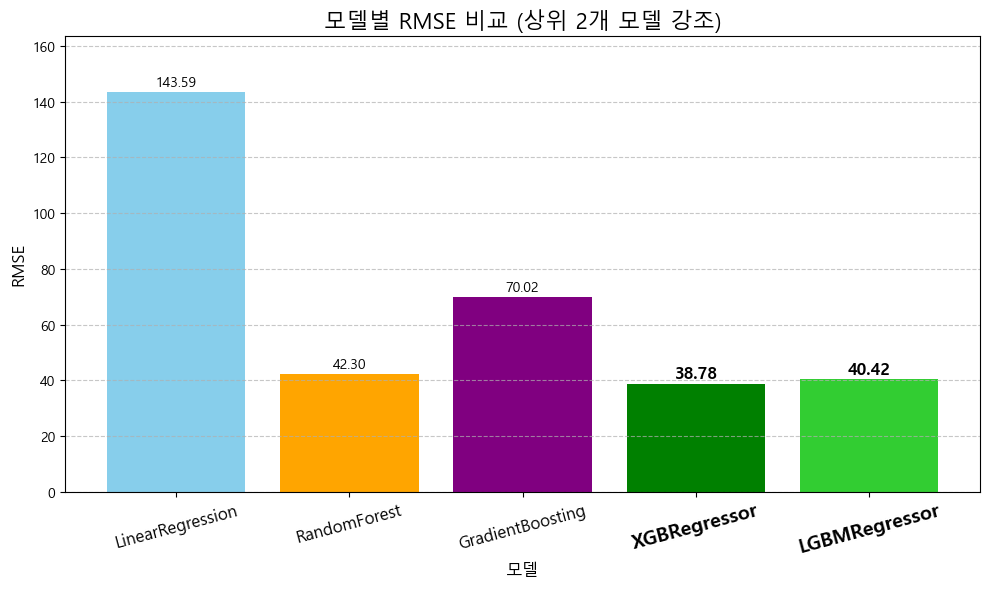

In [44]:
models = ['LinearRegression', 'RandomForest', 'GradientBoosting', 'XGBRegressor', 'LGBMRegressor']
rmse_values = [143.59, 42.30, 70.02, 38.78, 40.42]

# RMSE 기준으로 상위 2개(낮은 값) 인덱스 찾기
top2_indices = np.argsort(rmse_values)[:2]

base_colors = ['skyblue', 'orange', 'purple', 'cyan', 'magenta']

colors = []
for i in range(len(models)):
    if i in top2_indices:
        colors.append('green' if i == top2_indices[0] else 'limegreen')
    else:
        colors.append(base_colors[i])

plt.figure(figsize=(10, 6))
bars = plt.bar(models, rmse_values, color=colors)
plt.title('모델별 RMSE 비교 (상위 2개 모델 강조)', fontsize=16)
plt.xlabel('모델', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.ylim(0, max(rmse_values) + 20)

# x축 글씨 스타일: 상위 2개는 굵고 크게
for i, label in enumerate(plt.gca().get_xticklabels()):
    if i in top2_indices:
        label.set_fontsize(14)
        label.set_fontweight('bold')
    else:
        label.set_fontsize(12)
        label.set_fontweight('normal')

plt.xticks(rotation=15)

# 막대 위 수치 표시
for i, bar in enumerate(bars):
    yval = bar.get_height()
    if i in top2_indices:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}', 
                 ha='center', fontsize=12, fontweight='bold', color='black')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}', 
                 ha='center', fontsize=10, color='black')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


RMSE를 기준으로 모델 2개 선정하여 하이퍼파라미터 조정

# XGBRegressor

In [49]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
import numpy as np

# 최소 탐색 범위의 하이퍼파라미터
param_grid = {
    'learning_rate': [0.1],  # 리스트로 감싸기
    'max_depth': [5],
    'n_estimators': [700],
    'subsample': [0.8]
}
# 모델 정의
xgb = XGBRegressor(random_state=42)

# GridSearchCV 설정
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)


grid_search.fit(X_train, y_train)

# 결과 출력
best_params = grid_search.best_params_
best_rmse = np.sqrt(-grid_search.best_score_)

print("최적 하이퍼파라미터:", best_params)
print("최고 CV RMSE:", round(best_rmse, 4))

# 최적 모델로 테스트셋 예측
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_test = np.maximum(y_pred_test, 0)  # 음수 예측 방지

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
rmsle_test = np.sqrt(mean_squared_log_error(y_test, y_pred_test))

print(f"Tuned XGBRegressor Test 결과: RMSE={rmse_test:.4f}, R2={r2_test:.4f}, RMSLE={rmsle_test:.4f}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
최적 하이퍼파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 700, 'subsample': 0.8}
최고 CV RMSE: 37.6702
Tuned XGBRegressor Test 결과: RMSE=37.6436, R2=0.9585, RMSLE=0.4762


# LGBM Train

In [34]:
from sklearn.model_selection import GridSearchCV
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error

# 하이퍼파라미터 후보
param_grid = {
    'learning_rate': [0.05],  # 단일 값도 리스트로 감싸기
    'max_depth': [20],
    'n_estimators': [500],
    'num_leaves': [50]
}

lgbm = lgb.LGBMRegressor(random_state=42)

# GridSearchCV
grid = GridSearchCV(estimator=lgbm,
                    param_grid=param_grid,
                    cv=5,
                    scoring='neg_mean_squared_error',
                    n_jobs=-1,
                    verbose=2)

grid.fit(X_train, y_train)

print("최적 하이퍼파라미터:", grid.best_params_)

# GridSearchCV 내부 평가 점수로 CV RMSE 계산
best_cv_rmse = np.sqrt(-grid.best_score_)
print(f"CV RMSE (원본 y): {best_cv_rmse:.4f}")

# 최적 모델
best_model = grid.best_estimator_

# 최적 모델로 테스트셋 예측
y_pred_test = best_model.predict(X_test)
y_pred_test = np.maximum(y_pred_test, 0)  # 음수 예측 방지

# 평가
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
rmsle_test = np.sqrt(mean_squared_log_error(y_test, y_pred_test))

print(f"Tuned LGBM Test 결과: RMSE={rmse_test:.4f}, R2={r2_test:.4f}, RMSLE={rmsle_test:.4f}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
최적 하이퍼파라미터: {'learning_rate': 0.05, 'max_depth': 20, 'n_estimators': 500, 'num_leaves': 50}
CV RMSE (원본 y): 37.3254
Tuned LGBM Test 결과: RMSE=37.5303, R2=0.9587, RMSLE=0.4038


In [35]:
# 하이퍼파라미터 최소 탐색 범위 설정
param_grid_minimal = {
    'learning_rate': [0.04, 0.05, 0.06],
    'max_depth': [14, 15, 16],
    'num_leaves': [45, 50, 55],
    'n_estimators': [550, 600, 650]
}

lgbm = lgb.LGBMRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_minimal,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# 원본 y로 학습
grid_search.fit(X_train, y_train)

# 결과 출력
best_params = grid_search.best_params_
best_rmse = np.sqrt(-grid_search.best_score_)

print("최적 하이퍼파라미터:", best_params)
print("최고 CV RMSE:", round(best_rmse, 4))

# 최적 모델로 훈련셋 예측
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred = np.maximum(y_pred, 0)  # 음수 예측 방지

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))

print(f"Tuned LGBM Test 결과: RMSE={rmse:.4f}, R2={r2:.4f}, RMSLE={rmsle:.4f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
최적 하이퍼파라미터: {'learning_rate': 0.05, 'max_depth': 16, 'n_estimators': 650, 'num_leaves': 50}
최고 CV RMSE: 37.1475
Tuned LGBM Test 결과: RMSE=37.2402, R2=0.9593, RMSLE=0.4126


In [36]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
import lightgbm as lgb
import numpy as np

# 하이퍼파라미터 그리드
param_grid_fine = {
    'num_leaves': [60],
    'n_estimators': [650],
    'min_child_samples': [10],
    'max_depth': [15],
    'learning_rate': [0.05],
    'feature_fraction': [0.7],
    'bagging_freq': [5],
    'bagging_fraction': [0.9]
}

# 모델 정의
lgbm = lgb.LGBMRegressor(random_state=42)

# RandomizedSearchCV
grid_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid_fine,
    n_iter=200,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# 학습
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 출력
print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최고 CV 점수 (neg_mean_squared_error):", grid_search.best_score_)
print("최고 CV RMSE:", np.sqrt(-grid_search.best_score_))

# 최적 모델로 전체 학습셋 예측
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred = np.maximum(y_pred, 0)  # 음수 예측 방지



rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))

print(f"\nTuned LGBM Test 결과:")
print(f"RMSE = {rmse:.4f}")
print(f"R2   = {r2:.4f}")
print(f"RMSLE= {rmsle:.4f}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\model_selection\_search.py:318: UserWarning: The total space of parameters 1 is smaller than n_iter=200. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
최적 하이퍼파라미터: {'num_leaves': 60, 'n_estimators': 650, 'min_child_samples': 10, 'max_depth': 15, 'learning_rate': 0.05, 'feature_fraction': 0.7, 'bagging_freq': 5, 'bagging_fraction': 0.9}
최고 CV 점수 (neg_mean_squared_error): -1307.8009364345278
최고 CV RMSE: 36.16353047525266

Tuned LGBM Test 결과:
RMSE = 36.6122
R2   = 0.9607
RMSLE= 0.4201


| 모델                   | 하이퍼파라미터 요약                                                                                                                                                              | CV RMSE     | Test RMSE   | R² 점수      | RMSLE  |
| -------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------- | ----------- | ---------- | ------ |
| **XGBRegressor**     | `learning_rate=0.1`, `max_depth=5`, `n_estimators=700`, `subsample=0.8`                                                                                                 | 37.6702     | 37.6436     | 0.9585     | 0.4762 |
| **LGBM #1**          | `learning_rate=0.05`, `max_depth=20`, `n_estimators=500`, `num_leaves=50`                                                                                               | 37.3254     | 37.5303     | 0.9587     | 0.4038 |
| **LGBM #2**          | `learning_rate=0.05`, `max_depth=16`, `n_estimators=650`, `num_leaves=50`                                                                                               | 37.1475     | 37.2402     | 0.9593     | 0.4126 |
| **LGBM Final Model** | `learning_rate=0.05`, `max_depth=15`, `n_estimators=650`, `num_leaves=60`, `min_child_samples=10`, <br>`feature_fraction=0.7`, `bagging_fraction=0.9`, `bagging_freq=5` | **36.1635** | **36.6122** | **0.9607** | 0.4201 |


결과: LGBM Final Model이 가장좋다

# 로그 변환 vs 미변환 모델 비교

In [42]:
# 로그 변환된 타깃 변수
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 모델 생성
lgbm_log = LGBMRegressor(random_state=42)
lgbm_raw = LGBMRegressor(random_state=42)

# 모델 학습
lgbm_log.fit(X_train, y_train_log)
lgbm_raw.fit(X_train, y_train)

# 예측
y_pred_log = np.expm1(lgbm_log.predict(X_test))  # 역변환
y_pred_raw = lgbm_raw.predict(X_test)

# 평가 지표 계산
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)
r2_log = r2_score(y_test, y_pred_log)

mse_raw = mean_squared_error(y_test, y_pred_raw)
rmse_raw = np.sqrt(mse_raw)
r2_raw = r2_score(y_test, y_pred_raw)

# 결과
results = pd.DataFrame({
    "모델": ["로그 변환", "미변환"],
    "MSE": [mse_log, mse_raw],
    "RMSE": [rmse_log, rmse_raw],
    "R²": [r2_log, r2_raw]
})

print(results)


      모델          MSE       RMSE        R²
0  로그 변환  2047.265383  45.246717  0.939982
1    미변환  1635.065277  40.435940  0.952066


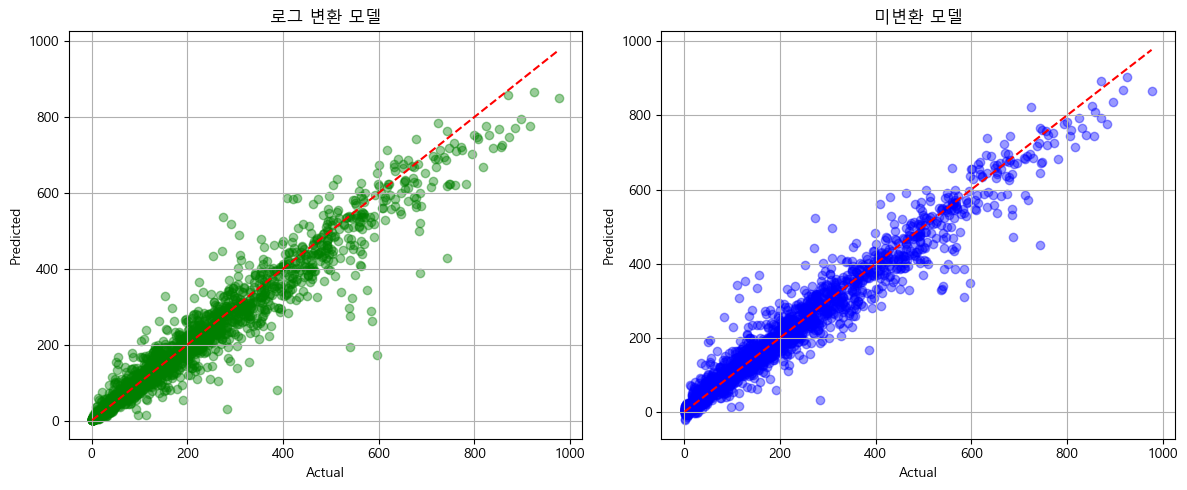

In [41]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_log, alpha=0.4, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("로그 변환 모델")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_raw, alpha=0.4, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("미변환 모델")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)

plt.tight_layout()
plt.show()


| 모델    | MSE     | RMSE  | R²      |
| ----- | ------- | ----- | ------- |
| 로그 변환 | 2047.27 | 45.25 | 0.93998 |
| 미변환   | 1635.07 | 40.44 | 0.95207 |


In [43]:
# 로그 변환 타깃 변수
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 모델 리스트 생성 (이름, 생성자)
models = [
    ("GradientBoosting", GradientBoostingRegressor(random_state=42)),
    ("LGBMRegressor", LGBMRegressor(random_state=42)),
    ("LinearRegression", LinearRegression()),
    ("RandomForest", RandomForestRegressor(random_state=42)),
    ("XGBRegressor", XGBRegressor(random_state=42))
]

# 결과 저장용 리스트
results = []

# 각 모델별 로그 변환 / 미변환 학습, 예측, 평가 반복
for name, model in models:
    # 로그 변환 모델 학습 및 예측 (역변환 포함)
    model.fit(X_train, y_train_log)
    y_pred_log = np.expm1(model.predict(X_test))
    
    mse_log = mean_squared_error(y_test, y_pred_log)
    rmse_log = np.sqrt(mse_log)
    r2_log = r2_score(y_test, y_pred_log)
    
    results.append({
        "모델": name,
        "변환": "로그 변환",
        "MSE": mse_log,
        "RMSE": rmse_log,
        "R²": r2_log
    })
    
    # 미변환 모델 학습 및 예측
    model.fit(X_train, y_train)
    y_pred_raw = model.predict(X_test)
    
    mse_raw = mean_squared_error(y_test, y_pred_raw)
    rmse_raw = np.sqrt(mse_raw)
    r2_raw = r2_score(y_test, y_pred_raw)
    
    results.append({
        "모델": name,
        "변환": "미변환",
        "MSE": mse_raw,
        "RMSE": rmse_raw,
        "R²": r2_raw
    })

# 결과 데이터프레임 생성 및 출력
results_df = pd.DataFrame(results)
print(results_df)


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-pa

                 모델     변환           MSE        RMSE        R²
0  GradientBoosting  로그 변환   5917.872196   76.927708  0.826511
1  GradientBoosting    미변환   4921.791845   70.155483  0.855712
2     LGBMRegressor  로그 변환   2047.265383   45.246717  0.939982
3     LGBMRegressor    미변환   1635.065277   40.435940  0.952066
4  LinearRegression  로그 변환  27171.858625  164.838887  0.203426
5  LinearRegression    미변환  20808.581605  144.251799  0.389973
6      RandomForest  로그 변환   1840.632932   42.902598  0.946040
7      RandomForest    미변환   1789.223586   42.299215  0.947547
8      XGBRegressor  로그 변환   1747.232491   41.799910  0.948778
9      XGBRegressor    미변환   1511.746049   38.881179  0.955681


| 모델               | 변환    | MSE          | RMSE       | R²       |
| ---------------- | ----- | ------------ | ---------- | -------- |
| GradientBoosting | 로그 변환 | 5917.872196  | 76.927708  | 0.826511 |
| GradientBoosting | 미변환   | 4921.791845  | 70.155483  | 0.855712 |
| LGBMRegressor    | 로그 변환 | 2047.265383  | 45.246717  | 0.939982 |
| LGBMRegressor    | 미변환   | 1635.065277  | 40.435940  | 0.952066 |
| LinearRegression | 로그 변환 | 27171.858625 | 164.838887 | 0.203426 |
| LinearRegression | 미변환   | 20808.581605 | 144.251799 | 0.389973 |
| RandomForest     | 로그 변환 | 1840.632932  | 42.902598  | 0.946040 |
| RandomForest     | 미변환   | 1789.223586  | 42.299215  | 0.947547 |
| XGBRegressor     | 로그 변환 | 1747.232491  | 41.799910  | 0.948778 |
| XGBRegressor     | 미변환   | 1511.746049  | 38.881179  | 0.955681 |



비선형, 트리 기반 모델들은 타깃 분포 왜곡에 강인하여 로그 변환 효과가 미미한 경향을 보인다.

In [72]:
y.describe()

count    10885.000000
mean       191.576665
std        181.152582
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64